# import the libraries and load your original saved dataset

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Support running the notebook from either the project
# root or the analytics directory.
data_path = Path("analytics/titanic.csv")

if not data_path.exists():
    data_path = Path("titanic.csv")

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# Select the features and target

In [2]:

features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

X = df[features]
y = df["survived"]

print("Features:", X.columns.tolist())
print("\nTarget distribution:")
print(y.value_counts())
print("\nTarget percentages:")
print((y.value_counts(normalize=True) * 100).round(2))

Features: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']

Target distribution:
survived
0    549
1    342
Name: count, dtype: int64

Target percentages:
survived
0    61.62
1    38.38
Name: proportion, dtype: float64


# Perform a stratified train/test split

In [3]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

print("\nTraining survival distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest survival distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training samples: 712
Test samples: 179

Training survival distribution:
survived
0    0.617
1    0.383
Name: proportion, dtype: float64

Test survival distribution:
survived
0    0.615
1    0.385
Name: proportion, dtype: float64


# Build the preprocessing pipeline

In [4]:

numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline,
         categorical_features)
    ]
)

print("Preprocessing pipeline created!")
print(preprocessor)

Preprocessing pipeline created!
ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['pclass', 'age', 'sibsp', 'parch', 'fare']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['sex', 'embarked'])])


# Train your first classifier: Logistic Regression

In [5]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

# Fit preprocessing and classifier on training data only.
logistic_model.fit(X_train, y_train)

# Predict the held-out test set.
y_pred = logistic_model.predict(X_test)

# Probability of survival for ROC-AUC.
y_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic regression test metrics")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")

Logistic regression test metrics
Accuracy:  0.8045
Precision: 0.7931
Recall:    0.6667
F1 score:  0.7244
ROC-AUC:   0.8437


# Plot the confusion matrix and ROC curve

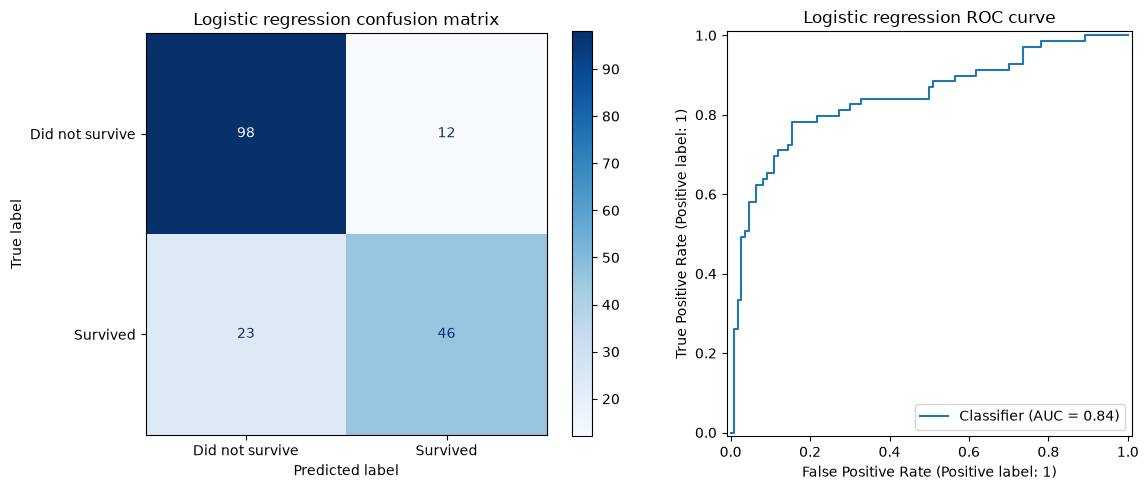

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Did not survive", "Survived"],
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("Logistic regression confusion matrix")

RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    ax=axes[1]
)
axes[1].set_title("Logistic regression ROC curve")

plt.tight_layout()
plt.show()

# Logistic regression interpretation:

Logistic regression achieved 80.45% accuracy, 79.31% precision, 66.67% recall and an F1 score of 72.44% on the held-out test set. The confusion matrix shows 98 true negatives, 46 true positives, 12 false positives and 23 false negatives. The ROC-AUC of 0.8437 indicates that the model distinguishes reasonably well between survivors and non-survivors, although its recall shows that it misses approximately one-third of actual survivors.

# Train a decision tree

In [7]:

from sklearn.tree import DecisionTreeClassifier, plot_tree

decision_tree = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            max_depth=4,
            random_state=42
        ))
    ]
)

decision_tree.fit(X_train, y_train)

dt_pred = decision_tree.predict(X_test)
dt_prob = decision_tree.predict_proba(X_test)[:, 1]

print("Decision tree test metrics")
print(f"Accuracy:  {accuracy_score(y_test, dt_pred):.4f}")
print(f"Precision: {precision_score(y_test, dt_pred):.4f}")
print(f"Recall:    {recall_score(y_test, dt_pred):.4f}")
print(f"F1 score:  {f1_score(y_test, dt_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, dt_prob):.4f}")

Decision tree test metrics
Accuracy:  0.7933
Precision: 0.8636
Recall:    0.5507
F1 score:  0.6726
ROC-AUC:   0.8292


# Visualize the decision tree

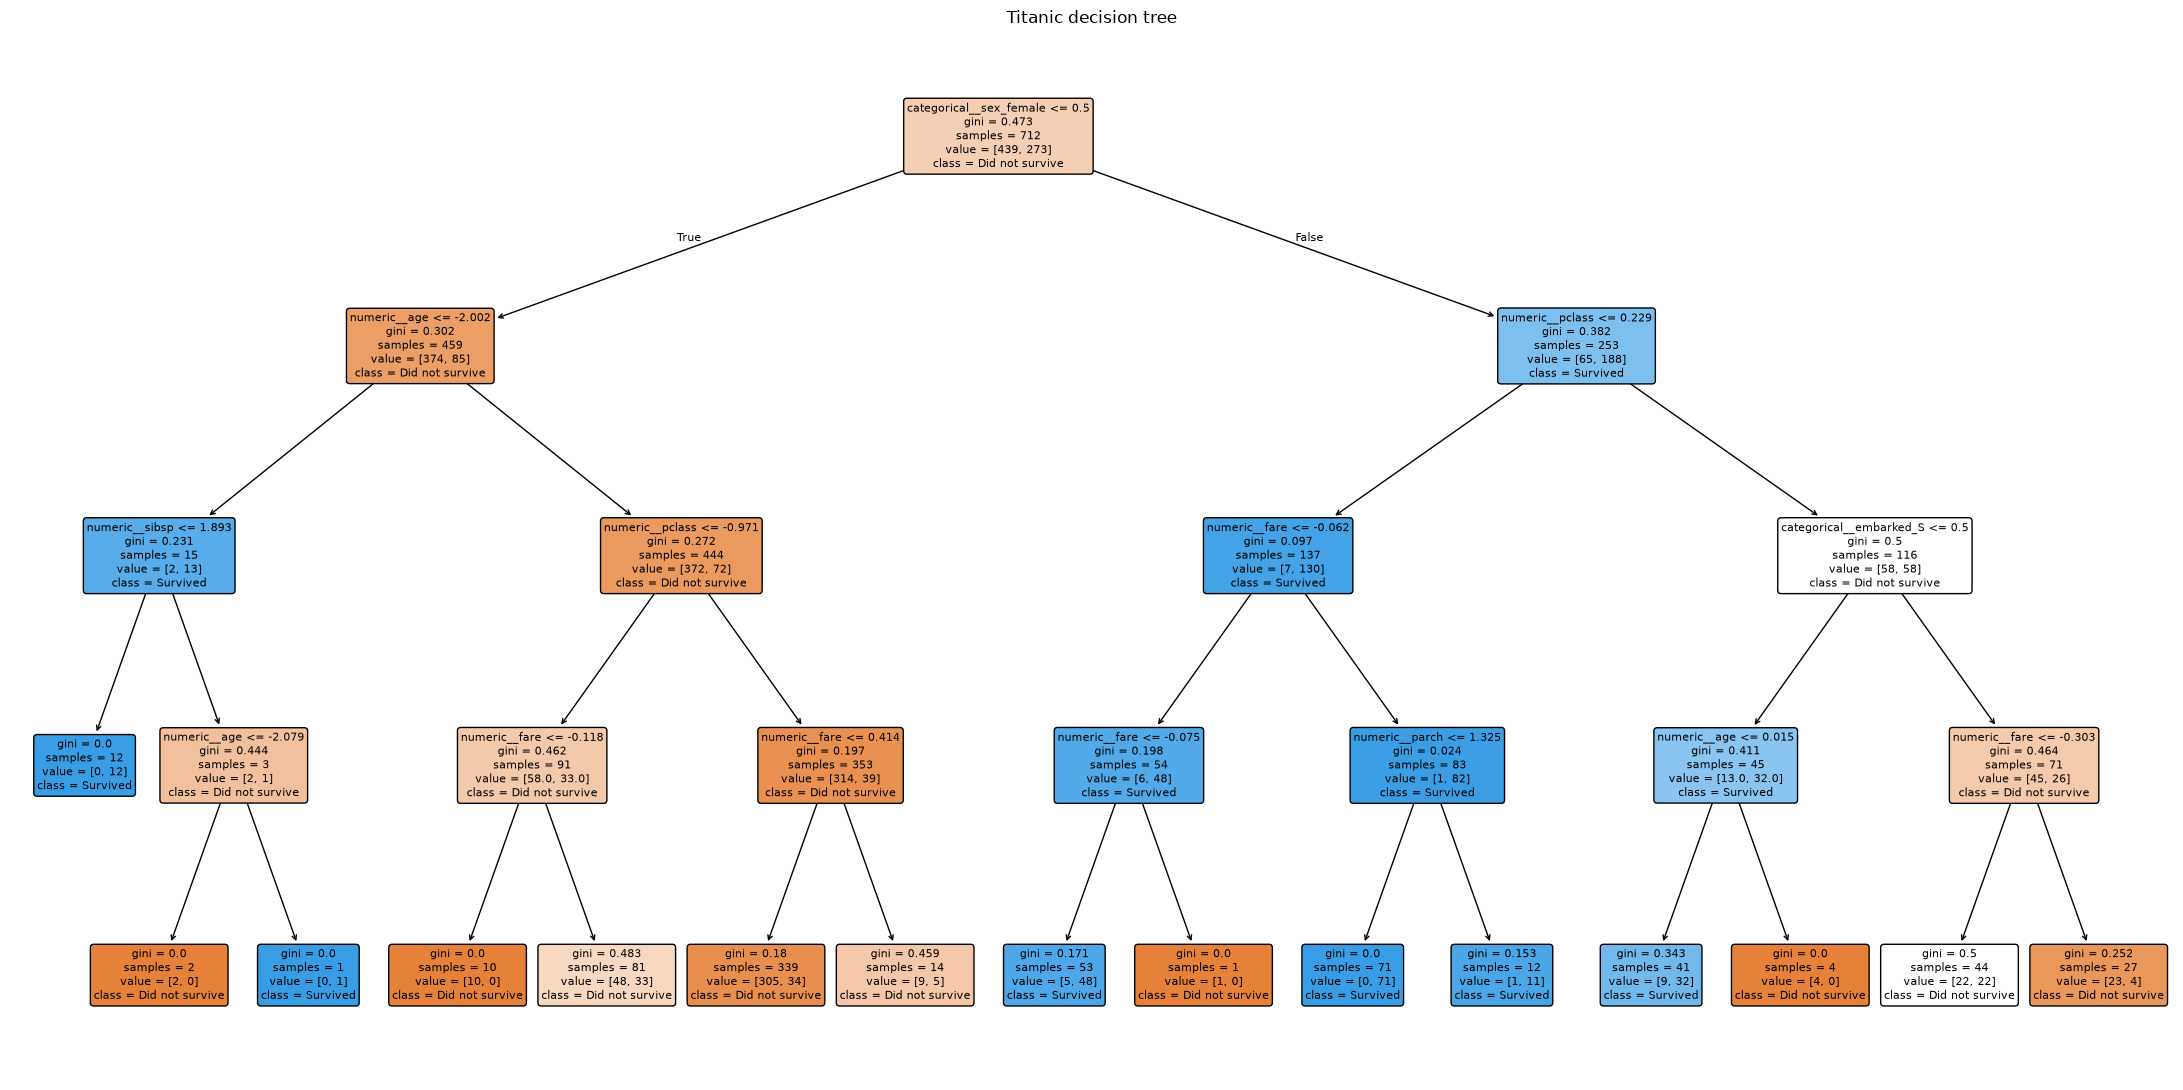

In [8]:

feature_names = (
    decision_tree
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

tree_classifier = (
    decision_tree.named_steps["classifier"]
)

plt.figure(figsize=(22, 11))

plot_tree(
    tree_classifier,
    feature_names=feature_names,
    class_names=["Did not survive", "Survived"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Titanic decision tree")
plt.tight_layout()
plt.show()

# Train a random forest

In [9]:

from sklearn.ensemble import RandomForestClassifier

random_forest = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            max_depth=6,
            random_state=42,
            oob_score=True,
            n_jobs=-1
        ))
    ]
)

random_forest.fit(X_train, y_train)

rf_pred = random_forest.predict(X_test)
rf_prob = random_forest.predict_proba(X_test)[:, 1]

print("Random forest test metrics")
print(f"Accuracy:  {accuracy_score(y_test, rf_pred):.4f}")
print(f"Precision: {precision_score(y_test, rf_pred):.4f}")
print(f"Recall:    {recall_score(y_test, rf_pred):.4f}")
print(f"F1 score:  {f1_score(y_test, rf_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, rf_prob):.4f}")

print(
    "OOB score:",
    round(
        random_forest.named_steps["classifier"].oob_score_,
        4
    )
)

Random forest test metrics
Accuracy:  0.8156
Precision: 0.8750
Recall:    0.6087
F1 score:  0.7179
ROC-AUC:   0.8457
OOB score: 0.823


# Plot both confusion matrices and ROC curves

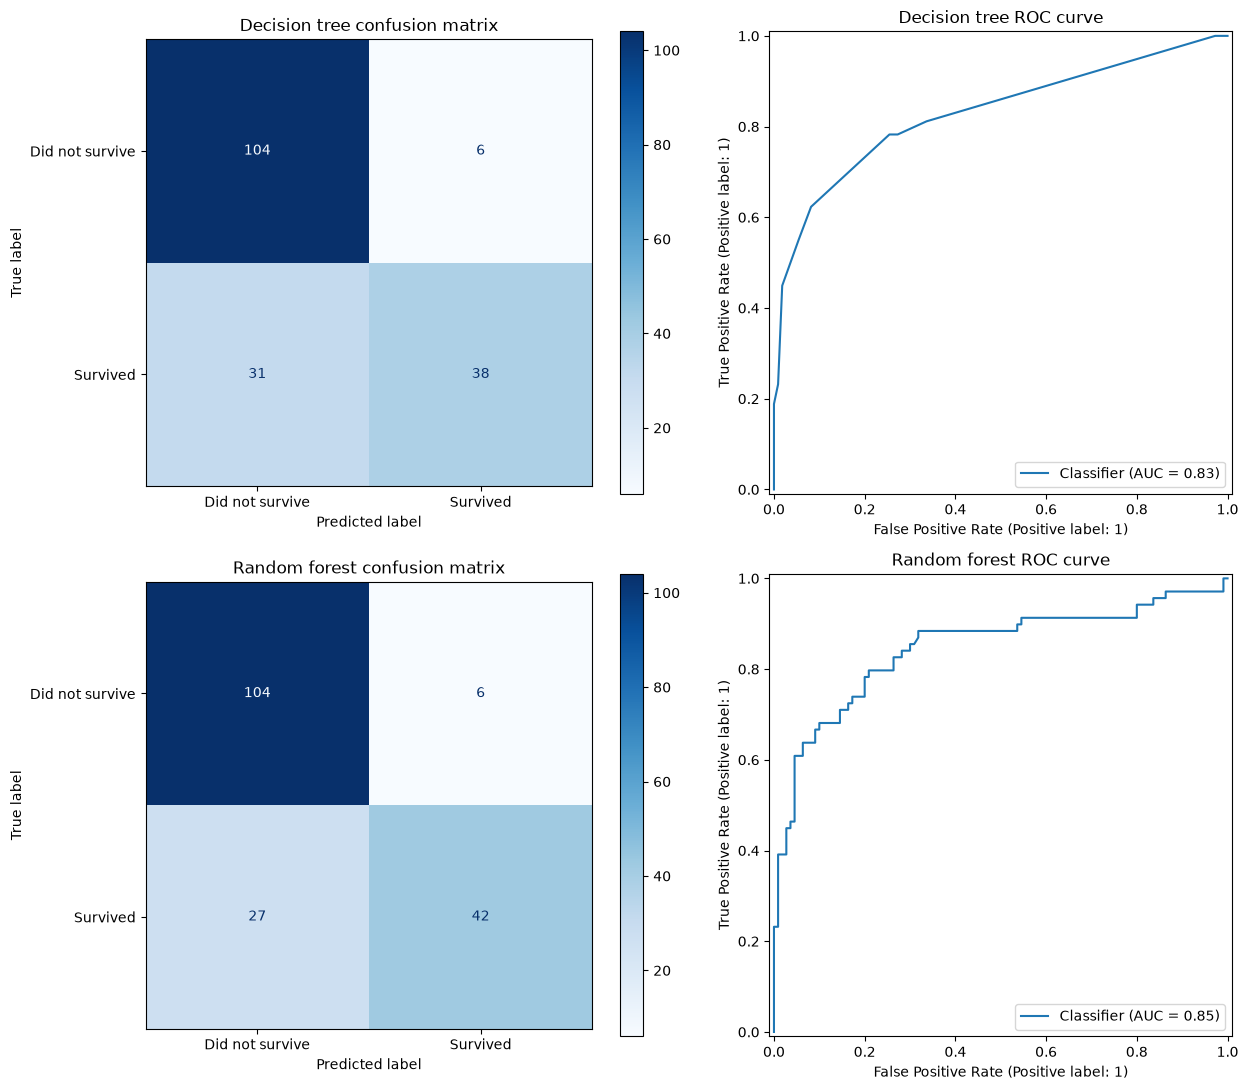

In [10]:

fig, axes = plt.subplots(2, 2, figsize=(13, 11))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_pred,
    display_labels=["Did not survive", "Survived"],
    cmap="Blues",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Decision tree confusion matrix")

RocCurveDisplay.from_predictions(
    y_test,
    dt_prob,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Decision tree ROC curve")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=["Did not survive", "Survived"],
    cmap="Blues",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Random forest confusion matrix")

RocCurveDisplay.from_predictions(
    y_test,
    rf_prob,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Random forest ROC curve")

plt.tight_layout()
plt.show()

# Compare all three classifiers

In [11]:

def model_metrics(name, predictions, probabilities):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, probabilities)
    }


comparison = pd.DataFrame([
    model_metrics(
        "Logistic Regression", y_pred, y_prob
    ),
    model_metrics(
        "Decision Tree", dt_pred, dt_prob
    ),
    model_metrics(
        "Random Forest", rf_pred, rf_prob
    )
])

display(comparison.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8045,0.7931,0.6667,0.7244,0.8437
1,Decision Tree,0.7933,0.8636,0.5507,0.6726,0.8292
2,Random Forest,0.8156,0.8750,0.6087,0.7179,0.8457


# Interpretation for three models
The random forest achieved the highest test accuracy (81.56%), precision (87.50%) and ROC-AUC (0.8457) among the three initial models. Logistic regression achieved the highest recall (66.67%) and F1 score (72.44%), indicating a different balance between identifying actual survivors and limiting incorrect survival predictions. The decision tree had relatively high precision (86.36%) but lower recall (55.07%), meaning it missed a larger proportion of actual survivors. The differences demonstrate why model evaluation should consider several metrics rather than accuracy alone.

# Class imbalance and random forest tuning
The dataset contains more non-survivors than survivors. We'll investigate whether adjusting for this imbalance changes model performance, then tune the random forest.

# Establish a majority-class baseline

First, compare your classifiers with a simple model that always predicts the majority class.

In [12]:

from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(X_train, y_train)

dummy_pred = dummy_model.predict(X_test)

print("Majority-class baseline")
print(f"Accuracy: {accuracy_score(y_test, dummy_pred):.4f}")
print(f"Recall:   {recall_score(y_test, dummy_pred):.4f}")
print(f"F1:       {f1_score(y_test, dummy_pred):.4f}")

Majority-class baseline
Accuracy: 0.6145
Recall:   0.0000
F1:       0.0000


This demonstrates why accuracy alone can be misleading: a model that predicts every passenger as a non-survivor can achieve substantial accuracy while identifying no survivors.

# Train a class-weighted logistic regression

class_weight="balanced" increases the penalty for misclassifying the less frequent class.

In [13]:

weighted_logistic = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ]
)

weighted_logistic.fit(X_train, y_train)

weighted_pred = weighted_logistic.predict(X_test)
weighted_prob = weighted_logistic.predict_proba(X_test)[:, 1]

print("Class-weighted logistic regression")
print(f"Accuracy:  {accuracy_score(y_test, weighted_pred):.4f}")
print(f"Precision: {precision_score(y_test, weighted_pred):.4f}")
print(f"Recall:    {recall_score(y_test, weighted_pred):.4f}")
print(f"F1:        {f1_score(y_test, weighted_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, weighted_prob):.4f}")

Class-weighted logistic regression
Accuracy:  0.8045
Precision: 0.7297
Recall:    0.7826
F1:        0.7552
ROC-AUC:   0.8464


# Tune the random forest using GridSearchCV

We'll search combinations of three hyperparameters: the number of trees, maximum tree depth and number of features considered at each split.

In [14]:

from sklearn.model_selection import GridSearchCV

rf_tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            random_state=42,
            oob_score=True,
            n_jobs=-1
        ))
    ]
)

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [4, 6, None],
    "classifier__max_features": ["sqrt", None]
}

grid_search = GridSearchCV(
    estimator=rf_tuning_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print(
    "Best cross-validation F1:",
    round(grid_search.best_score_, 4)
)

Best parameters:
{'classifier__max_depth': 6, 'classifier__max_features': None, 'classifier__n_estimators': 200}
Best cross-validation F1: 0.7514


# Model selection and data leakage prevention

The dataset was divided into stratified training (80%) and test (20%) sets before preprocessing. Imputation, scaling and categorical encoding were fitted within scikit-learn pipelines using training data only.

Random forest hyperparameters were selected using five-fold cross-validation on the training set, with F1 as the scoring metric. The held-out test set was used to report performance after tuning, rather than to select hyperparameters. No additional hyperparameter changes were made in response to the test results.

# Evaluate the tuned random forest

In [15]:

best_rf = grid_search.best_estimator_

tuned_pred = best_rf.predict(X_test)
tuned_prob = best_rf.predict_proba(X_test)[:, 1]

print("Tuned random forest test metrics")
print(f"Accuracy:  {accuracy_score(y_test, tuned_pred):.4f}")
print(f"Precision: {precision_score(y_test, tuned_pred):.4f}")
print(f"Recall:    {recall_score(y_test, tuned_pred):.4f}")
print(f"F1:        {f1_score(y_test, tuned_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, tuned_prob):.4f}")

print(
    "OOB score:",
    round(
        best_rf.named_steps["classifier"].oob_score_,
        4
    )
)

Tuned random forest test metrics
Accuracy:  0.8156
Precision: 0.8462
Recall:    0.6377
F1:        0.7273
ROC-AUC:   0.8446
OOB score: 0.8258


# Compare the original and updated models

In [16]:

updated_comparison = pd.DataFrame([
    model_metrics(
        "Original Logistic Regression",
        y_pred,
        y_prob
    ),
    model_metrics(
        "Weighted Logistic Regression",
        weighted_pred,
        weighted_prob
    ),
    model_metrics(
        "Original Random Forest",
        rf_pred,
        rf_prob
    ),
    model_metrics(
        "Tuned Random Forest",
        tuned_pred,
        tuned_prob
    )
])

display(updated_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Original Logistic Regression,0.8045,0.7931,0.6667,0.7244,0.8437
1,Weighted Logistic Regression,0.8045,0.7297,0.7826,0.7552,0.8464
2,Original Random Forest,0.8156,0.8750,0.6087,0.7179,0.8457
3,Tuned Random Forest,0.8156,0.8462,0.6377,0.7273,0.8446


The majority-class baseline achieved 61.45% accuracy but zero recall and F1, demonstrating that accuracy alone is insufficient for this imbalanced dataset. Class weighting increased logistic regression's recall from 66.67% to 78.26% and F1 from 72.44% to 75.52%, while precision decreased. Five-fold cross-validation selected a random forest with 200 trees, maximum depth of six and max_features=None, achieving a cross-validation F1 of 0.7514. The tuned model's held-out F1 was 0.7273, with an OOB score of 0.8258.

# Handle class imbalance with SMOTE
We've tested the majority-class baseline and class weighting. Now we'll evaluate SMOTE, which creates synthetic minority-class training examples.

The critical rule is to apply SMOTE inside the training pipeline, after preprocessing. Never apply it to the full dataset before the train/test split.

# Create a SMOTE pipeline

In [17]:

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_val_score

smote_logistic = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

# Evaluate with cross-validation on training data only.
smote_cv = cross_val_score(
    smote_logistic,
    X_train,
    y_train,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

print("SMOTE cross-validation F1 scores:")
print(smote_cv.round(4))
print("Mean CV F1:", round(smote_cv.mean(), 4))

SMOTE cross-validation F1 scores:
[0.7304 0.6857 0.7377 0.7568 0.7304]
Mean CV F1: 0.7282


# Fit and evaluate the SMOTE model

In [18]:

smote_logistic.fit(X_train, y_train)

smote_pred = smote_logistic.predict(X_test)
smote_prob = smote_logistic.predict_proba(X_test)[:, 1]

print("SMOTE logistic regression test metrics")
print(f"Accuracy:  {accuracy_score(y_test, smote_pred):.4f}")
print(f"Precision: {precision_score(y_test, smote_pred):.4f}")
print(f"Recall:    {recall_score(y_test, smote_pred):.4f}")
print(f"F1:        {f1_score(y_test, smote_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, smote_prob):.4f}")

SMOTE logistic regression test metrics
Accuracy:  0.8101
Precision: 0.7397
Recall:    0.7826
F1:        0.7606
ROC-AUC:   0.8414


# Compare the three imbalance strategies

In [19]:

imbalance_comparison = pd.DataFrame([
    model_metrics(
        "Original Logistic Regression",
        y_pred,
        y_prob
    ),
    model_metrics(
        "Class-weighted Logistic Regression",
        weighted_pred,
        weighted_prob
    ),
    model_metrics(
        "SMOTE Logistic Regression",
        smote_pred,
        smote_prob
    )
])

display(imbalance_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Original Logistic Regression,0.8045,0.7931,0.6667,0.7244,0.8437
1,Class-weighted Logistic Regression,0.8045,0.7297,0.7826,0.7552,0.8464
2,SMOTE Logistic Regression,0.8101,0.7397,0.7826,0.7606,0.8414


Both class weighting and SMOTE improved logistic regression's recall from 66.67% to 78.26%, at the expense of precision. SMOTE achieved slightly higher precision (73.97%) than class weighting (72.97%), while maintaining identical recall. It also achieved a slightly higher test F1 score of 76.06%, compared with 75.52% for class weighting and 72.44% for the original model. These results demonstrate how imbalance-handling techniques can improve the identification of survivors while introducing a trade-off in false-positive predictions.

# Save the trained model

In [20]:

from pathlib import Path
import joblib

model_dir = Path("models")
model_dir.mkdir(exist_ok=True)

model_path = model_dir / "titanic_classifier.joblib"

joblib.dump(weighted_logistic, model_path)

print(f"Model saved to: {model_path}")
print(f"File size: {model_path.stat().st_size:,} bytes")

Model saved to: models/titanic_classifier.joblib
File size: 4,458 bytes


# Reload the model

In [21]:

loaded_model = joblib.load(model_path)

print("Model loaded successfully.")

# Confirm that the reloaded model produces the same predictions.
original_predictions = weighted_logistic.predict(X_test)
loaded_predictions = loaded_model.predict(X_test)

assert np.array_equal(
    original_predictions,
    loaded_predictions
), "Reloaded model predictions do not match!"

print("Verification passed: predictions are identical.")

Model loaded successfully.
Verification passed: predictions are identical.


# Predict survival for a new passenger

In [22]:

new_passenger = pd.DataFrame([{
    "pclass": 2,
    "sex": "female",
    "age": 28,
    "sibsp": 0,
    "parch": 0,
    "fare": 25.0,
    "embarked": "S"
}])

prediction = loaded_model.predict(new_passenger)[0]
probability = loaded_model.predict_proba(new_passenger)[0, 1]

print("Predicted class:", prediction)
print(f"Predicted survival probability: {probability:.2%}")
print(
    "Prediction:",
    "Survived" if prediction == 1 else "Did not survive"
)

Predicted class: 1
Predicted survival probability: 86.62%
Prediction: Survived
